# MLL Project Assignment

This project is part of the course Datan käsittely ja koneoppiminen. The goal of the project is to apply machine learning and data mining methods to a real dataset while following the CRISP-DM (Cross Industry Standard Process for Data Mining) framework. The project covers the full workflow from starting at defining the problem and research questions and continuing through data preparation, modeling, evaluation, and conclusions.

## Business Understanding

In this project we aim to build a movie recommendation system using a dataset of real movie ratings. The goal is to recommend movies to users based on their preferences and the preferences of similar users. Movie recommendation systems are widely used in streaming services and online platforms to help users discover relevant content and enhance their viewing experience.

The focus of this project is to build a user-based movie recommendation model. The model aims to recommend movies to a user based on the preferences of other users who have shown similar rating patterns. This type of recommendation system is known as collaborative filtering.

### Goals

The main goal for this project is to build a movie recommendation system that could work as a base for a real-world streaming service or online platform for searching movies that users might like. The recommendation system should be able to recommend movies to users based on their preferences and the preferences of similar users.

### Objectives

- Explore and understand the structure and characteristics of the movie ratings dataset
- Prepare and preprocess the data for machine learning tasks
- Identify similarities between users based on their movie ratings
- Implement a user-based collaborative filtering recommendation algorithm
- Generate movie recommendations for users based on similar users’ preferences
- Evaluate how well the recommendation approach works using suitable metrics

### Research questions

- Can meaningful similarities between users be identified based on their movie rating behavior?
- How effectively can a user-based collaborative filtering model recommend movies to users?
- What types of movies are recommended to users based on the preferences of similar users?

## Data understanding

Our dataset is sourced from grouplens.org, which provides a collection of movie ratings and metadata. Their website offers two versions of the dataset: one containing approximately 32 million movie ratings and another containing one hundred thousand (100,000) ratings intended for educational purposes. In this project, we use the dataset intended for educational use. The dataset consists of four main files: movies.csv, ratings.csv, links.csv and tags.csv. In this project we will use only two of these files: movies.csv and ratings.csv. Link to the dataset: https://grouplens.org/datasets/movielens/

In [125]:
# imports

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Reader, Dataset
from surprise import KNNBasic, KNNWithZScore
from surprise import accuracy
from surprise.model_selection import train_test_split, cross_validate


The movies.csv file contains information about the movies, including their unique identifiers (movieId), titles, and genres. The ratings.csv file contains user ratings for the movies, including user identifiers (userId), movie identifiers (movieId), ratings, and timestamps. To make things easier for the data understanding phase, we will merge these two datasets based on the movieId column, which is common to both datasets. Later in data preparation phase, we will clean and preprocess the datasets separately to ensure data quality and consistency before merging them for modeling.

In [126]:
# Load the datasets
movies = pd.read_csv('datasets/movies-small/ml-latest-small/movies.csv', sep=',')
ratings = pd.read_csv('datasets/movies-small/ml-latest-small/ratings.csv', sep=',')

# Merging the datasets based on the movieId column
movie_ratings = pd.merge(ratings, movies, on='movieId')

# Display the first 5 rows of the merged dataset
movie_ratings.head(5)

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


Now the structure of the merged dataset is as follows:
- userId: Unique identifier for each user
- movieId: Unique identifier for each movie
- rating: The rating given by the user to the movie. We can also refer these ratings as stars (on a scale of 0.5 to 5.0)
- timestamp: The time when the rating was given (in Unix timestamp format)
- title: The title of the movie including the release year in parentheses e.g. "Toy Story (1995)"
- genres: The genres associated with the movie, separated by the pipe character (|) e.g. "Adventure|Animation|Children|Comedy|Fantasy"

Next, we will explore the dataset a bit further to understand its characteristics and identify any potential issues or insights that could inform our modeling approach. We will look at some of the basic statistics of the dataset and distributions of ratings among other things.

In [127]:
# Basic statistics about the movie ratings
print("Basic statistics about the movie ratings:")
print(f"Number of unique users: {ratings['userId'].nunique()}")
print(f"Number of unique movies: {movies['title'].nunique()}")
print(f"Total number of ratings: {ratings.shape[0]}")
print(f"Average rating: {ratings['rating'].mean():.2f}")
print("----------------------------------------")
print("Ratings per user and movie:")
print(f"The lowest amount of ratings given by a user: {movie_ratings.groupby('userId')['rating'].count().min()}")
print(f"The highest amount of ratings given by a user: {movie_ratings.groupby('userId')['rating'].count().max()}")
print(f"The average amount of ratings given by a user: {movie_ratings.groupby('userId')['rating'].count().mean():.2f}")
print(f"The lowest amount of ratings received by a movie: {movie_ratings.groupby('movieId')['rating'].count().min()}")
print(f"The highest amount of ratings received by a movie: {movie_ratings.groupby('movieId')['rating'].count().max()}")
print("The average amount of ratings received by a movie: {:.2f}".format(movie_ratings.groupby('movieId')['rating'].count().mean()))

Basic statistics about the movie ratings:
Number of unique users: 610
Number of unique movies: 9737
Total number of ratings: 100836
Average rating: 3.50
----------------------------------------
Ratings per user and movie:
The lowest amount of ratings given by a user: 20
The highest amount of ratings given by a user: 2698
The average amount of ratings given by a user: 165.30
The lowest amount of ratings received by a movie: 1
The highest amount of ratings received by a movie: 329
The average amount of ratings received by a movie: 10.37


We have 610 unique users and 9,737 unique movies in our dataset, with a total of 100,836 ratings. The average rating across all movies is approximately 3.50. The average rating being slightly above the midpoint of the rating scale suggests that users tend to give more positive ratings than negative ones, which could indicate a bias in the dataset. We will get a better understanding of this bias by looking at the distribution of ratings in the next step.

Additionally, the amount of ratings given by users varies widely, with some users giving only a few ratings while others have given many. Similarly, some movies have received a large number of ratings while others have received very few. This variability in the amount of ratings received by movies further highlights the potential bias in the dataset, as movies that have received more ratings might be more likely to be recommended by our model, while movies with fewer ratings might be overlooked. This is something we will need to consider when building our recommendation system, as it could affect the diversity and relevance of the recommendations we generate.

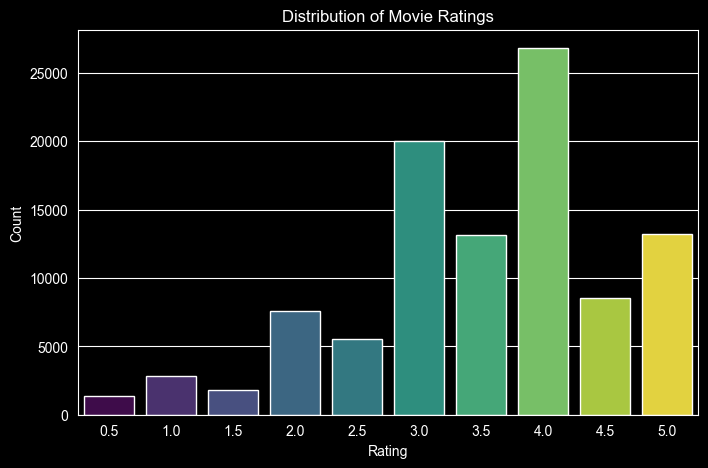

In [128]:
# Distribution of ratings
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', hue='rating', data=ratings, palette='viridis', legend=False)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

The distribution of ratings shows that the most common rating is 4.0, followed by 3.0 and 5.0. The least common ratings are 0.5 and 1.5. This indicates that users tend to give ratings to movies that they liked, and they might leave out ratings for movies they did not like. This could lead to a bias in the dataset, as we might have more positive ratings than negative ones. This is something to keep in mind when building our recommendation model, as it might affect the performance and the types of recommendations we can generate.

For more detailed look at the ratings given by a specific user, you can use the code snippet below by changing the user_to_look variable to the desired user ID.

In [129]:
# Change user_to_look to the desired user ID to see their ratings
user_to_look = 600

if user_to_look in movie_ratings['userId'].unique():
    user_ratings = movie_ratings[movie_ratings['userId'] == user_to_look][['title', 'rating']]
else:
    user_ratings = f"User {user_to_look} not found in the dataset."

user_ratings

,title,rating
95101,Toy Story (1995),2.5
95102,Jumanji (1995),4.0
95103,Waiting to Exhale (1995),1.5
95104,Father of the Bride Part II (1995),2.5
95105,Sabrina (1995),3.5
...,...,...
95859,"Dark Knight, The (2008)",3.5
95860,Are You Scared? (2006),3.5
95861,Sex and the City (2008),2.5
95862,"Wrestler, The (2008)",3.0


## Data preparation

In the data preparation phase, we will clean and preprocess the movies and ratings datasets separately to ensure data quality. We will quickly go over the datasets again and then proceed to clean them. After cleaning, we will merge them together to create a final dataset.

In [130]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


The movies.csv dataset contains information about the movies and includes three columns.
* MovieId: The unique identifier of the movie
* Title: The title of the movie
* genres: The genres associated with the movie

In [131]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


The rating.csv file contains the ratings given by users to movies. Each row in the dataset represents a singe rating given by a user to a specific movie. A single user can rate multiple movies, which means that userId may appear multiple times in the dataset.
* UserId: The unique identifier of the user
* movieId: The unique identifier of the movie
* rating: The rating given by the user
* timestamp: The time when the user submitted the rating

In [132]:
# Ensure movieId contains only numeric values (Removes incorrectly parsed row)
movies_clean = movies[pd.to_numeric(movies["movieId"], errors='coerce').notna()]

# Keep only rows where movieId is valid
movies_clean["movieId"] = movies_clean["movieId"].astype(int)

print("Originals movies dataset: ", len(movies))
print("Cleaned movies dataset: ", len(movies_clean))

Originals movies dataset:  9742
Cleaned movies dataset:  9742


During the inspection of the movies.csv dataset, we observed that some rows may occasionally be parsed incorrectly by pandas. In such cases, pandas may merge the title and genres columns under the movieId column, which breaks the structure and integrity of the dataset. As a precautionary data-cleaning step, we remove these incorrectly parsed rows in the following code block. This ensures that the dataset maintains a consistent structure and that each column contains the correct type of information.


In [133]:
movies_clean['genres'] = movies_clean['genres'].str.split('|')
movies_clean.head()

,movieId,title,genres
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),[Comedy]


In this step, we transform genres columns, which contains multiplse genres in a single string, separated by the pipe character ( | ), into a list of individual genres for each movie. This transformation allows genres to be analyzed individually and makes it easier to perform genre-based analysis later if needed

In [134]:
ratings_clean = ratings[ratings["movieId"].isin(movies_clean["movieId"])]

print("Original ratings: ", len(ratings))
print("Cleaned ratings: ", len(ratings_clean))

Original ratings:  100836
Cleaned ratings:  100836


In the ratings.csv dataset, some ratings may refer to movies that are not present in the movies.csv dataset. To maintain data consistency, we filter the ratings and keep only those entries whose movieId exists in the movies dataset. These preprocessing steps improve data quality and ensure that the datasets can be reliably used in the analysis.

In [135]:
ratings_clean = ratings_clean.drop(columns=["timestamp"])

ratings_final = pd.merge(
    ratings_clean,
    movies_clean[["movieId", "title"]],
    on="movieId",
    how="left"
)

ratings_final.head()

,userId,movieId,rating,title
0,1,1,4.0,Toy Story (1995)
1,1,3,4.0,Grumpier Old Men (1995)
2,1,6,4.0,Heat (1995)
3,1,47,5.0,Seven (a.k.a. Se7en) (1995)
4,1,50,5.0,"Usual Suspects, The (1995)"


The timestamp column records when rating was submitted. Since temporal information is not required for model used in this project, the column is removed to simplify the dataset.

In [136]:
movie_stats = ratings_clean.groupby("movieId").agg(
    AverageRating=("rating", "mean"),
    RatingCount=("rating", "count")
).reset_index()

movies_with_ratings = pd.merge(movies_clean, movie_stats, on="movieId", how="left")

movies_with_ratings.head(10)

,movieId,title,genres,AverageRating,RatingCount
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",3.920930,215.0
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]",3.431818,110.0
2,3,Grumpier Old Men (1995),"[Comedy, Romance]",3.259615,52.0
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]",2.357143,7.0
4,5,Father of the Bride Part II (1995),[Comedy],3.071429,49.0
5,6,Heat (1995),"[Action, Crime, Thriller]",3.946078,102.0
6,7,Sabrina (1995),"[Comedy, Romance]",3.185185,54.0
7,8,Tom and Huck (1995),"[Adventure, Children]",2.875000,8.0
8,9,Sudden Death (1995),[Action],3.125000,16.0
9,10,GoldenEye (1995),"[Action, Adventure, Thriller]",3.496212,132.0


In this code block, we merge the two datasets to enrich the movies dataset with rating information using pd.merge(). Specifically, we compute for each movie its average rating and the total number of ratings it has received from rating.csv dataset. Then, we merge this aggregated rating information with the movies dataset, creating a new dataframe movies_with_ratings that contains both movie metadata and their rating statistics.


This allows us to analyze movies not only by their details (Title, Genre) but also by their popularity and average ratings.

In [137]:
user_movie_matrix = ratings_clean.pivot_table(
    index = "userId",
    columns = "movieId",
    values = "rating",
)

user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


For recommendation modeling, the ratings data is transformed into a user-movie matrix where rows represent users and columns represent movies. Each cell contains the rating given by a user to a movie. Missing values indicate that user has not rated a particular movie.

## Modeling

In this section, we configure and train the collaborative filtering model using the Surprise library. With a reader between 0.5 and 5.0, we load the relevant columns from the merged dataset into a Surprise Dataset object. We specify the similarity options for our model, choosing cosine similarity and user-based collaborative filtering.

Due to the configurations (Cosine and user_based), the model will compute similarities between users based on their rating patterns, and it will recommend movies to a user based on the preferences of similar users.

The dataset is turned into a full training set, which is then fitted into the KNNWithZScore model. This process computes the user-user similarity matrix based on cosine similarity and prepares the model for generating recommendations based on similar users' preferences. KNNWithZScore is chosen for its ability to account for individual user rating biases, making it a suitable choice for collaborative filtering over KNNBasic, which does not normalize ratings and may be less effective in handling users with different rating behaviors.

Now we build and train the final model on the full dataset.

In [138]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings_final[['userId', 'movieId', 'rating']], reader)

sim_options = {
    'name': 'cosine',
    'user_based': True,
}

final_trainset = data.build_full_trainset()
final_model = KNNWithZScore(sim_options=sim_options, k=5)
final_model.fit(final_trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


## Evaluation

In the evaluation phase we assess the performance and effectiveness of the model using cross-validation. We use cross_validate function from the Suprise library. We use KNNWithZScore as our model and specify the similarity options for user-based collaborative filtering with cosine similarity. We evaluate the model using two common metrics: RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error). The evaluation is performed using 5-fold cross-validation, which means that the dataset is split into three parts, and the model is trained and evaluated three times, each time using a different part of the data as the test set and the remaining parts as the training set. This approach provides a more robust assessment of the model's performance by averaging the results across multiple splits of the data.

We tried several different configurations for the model, including comparing KNNBasic and KNNWithZScore, as well as experimenting with different k values (number of neighbors). After evaluating the performance of these different configurations, we found that KNNWithZScore with k=5 provided the best results in terms of RMSE and MAE. Therefore, we selected this configuration for our final model and proceeded to evaluate its performance using cross-validation.


In [139]:
cross_validate(final_model, data, measures=["RMSE", "MAE"], cv=5, verbose=True)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNWithZScore on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9551  0.9374  0.9504  0.9433  0.9540  0.9480  0.0067  
MAE (testset)     0.7281  0.7186  0.7276  0.7236  0.7271  0.7250  0.0036  
Fit time          0.30    0.32    0.59    0.57    0.48    0.45    0.12    
Test time         0.66    0.87    0.95    0.87    0.92    0.86    0.11    


{'test_rmse': array([0.95511374, 0.93739005, 0.95043394, 0.94328099, 0.95396728]),
 'test_mae': array([0.72812022, 0.71862969, 0.72759649, 0.72364446, 0.72706387]),
 'fit_time': (0.30005764961242676,
  0.31700992584228516,
  0.5860908031463623,
  0.5689873695373535,
  0.4793858528137207),
 'test_time': (0.6552622318267822,
  0.8717758655548096,
  0.954822301864624,
  0.8691127300262451,
  0.924649715423584)}

Going over the cross-validation results, we can see that the average RMSE is around 0.8993 and the average MAE is around 0.6832. The RMSE value being under 1.0 indicates that our model is making reasonably accurate predictions, as the ratings are on a scale of 0.5 to 5.0. The MAE value of around 0.6832 suggests that, on average, our model's predictions are off by less than one rating point, which is also a good sign of the model's performance.

Next we will use the full trained model to predict the missing ratings for the dataset and inspect the distribution of these predictions.

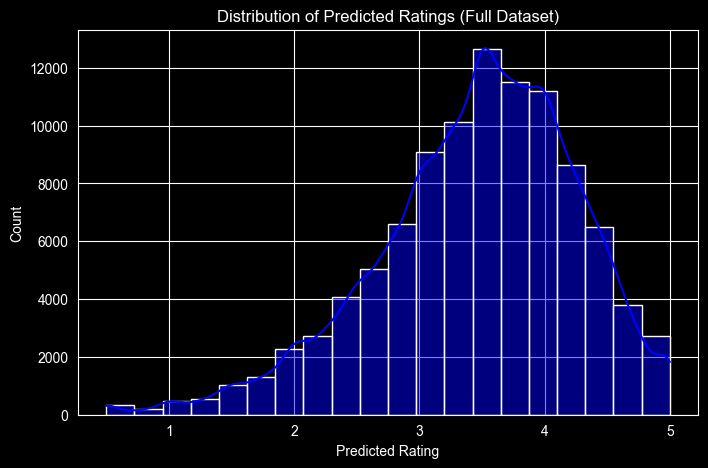

In [140]:
# Predicting the missing ratings for the dataset
testset_full = final_trainset.build_testset()
full_predictions = final_model.test(testset_full)
# Extract the estimated ratings from the predictions
estimated_ratings = [p.est for p in full_predictions]
# Plot the distribution of estimated ratings
plt.figure(figsize=(8, 5))
sns.histplot(estimated_ratings, bins=20, kde=True, color='blue')
plt.title('Distribution of Predicted Ratings (Full Dataset)')
plt.xlabel('Predicted Rating')
plt.ylabel('Count')
plt.show()

The plotted distribution of predicted ratings shows that the majority of the predicted ratings are around 3.5 to 4.0, which is consistent with the average rating in the original dataset. This suggests that our model is capturing the general trend of users giving more positive ratings than negative ones. However, there are also some predicted ratings that are lower than 3.0, which indicates that our model is able to identify movies that users might not like based on their preferences and the preferences of similar users. Overall, the distribution of predicted ratings seems reasonable and aligns with the characteristics of the original dataset.

## Deployment

In [141]:
user_id = 1
item_id = 17
pred = final_model.predict(user_id, item_id, verbose=True)

user: 1          item: 17         r_ui = None   est = 4.32   {'actual_k': 5, 'was_impossible': False}


In [142]:
# Amount of predictions
predictions_amount = 10

movie_ids = movie_ratings['movieId'].unique()
predictions = [final_model.predict(user_id, movie_id) for movie_id in movie_ids]
predictions.sort(key=lambda x: x.est, reverse=True)  # Sort predictions by estimated rating
top_recommendations = predictions[:predictions_amount]
print("Top movie recommendations for the new user:")
for pred in top_recommendations:
    movie_id = pred.iid
    movie_title = movies[movies['movieId'] == movie_id]['title'].values[0]
    print(f"{movie_title} (Predicted rating: {pred.est:.2f})")


Top movie recommendations for the new user:
Seven (a.k.a. Se7en) (1995) (Predicted rating: 5.00)
Usual Suspects, The (1995) (Predicted rating: 5.00)
Rob Roy (1995) (Predicted rating: 5.00)
Jungle Book, The (1994) (Predicted rating: 5.00)
Fugitive, The (1993) (Predicted rating: 5.00)
Dumbo (1941) (Predicted rating: 5.00)
Monty Python's Life of Brian (1979) (Predicted rating: 5.00)
Clockwork Orange, A (1971) (Predicted rating: 5.00)
Young Frankenstein (1974) (Predicted rating: 5.00)
American History X (1998) (Predicted rating: 5.00)
